In [1]:
pip install scikit.image

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
from sklearn import svm
import os
from skimage.transform import resize
from skimage.io import imread
import numpy as np
from skimage import io
from sklearn.model_selection import train_test_split


In [3]:
flat_data_arry = []
target_arr = []
categories = ['cats','dogs']
datadir = r'C:\Users\HP\Desktop\AI\ML\Supervised Learning\SVM\Image Classification\data'

In [4]:
for i in categories:

    print('loading....category :',i)
    path = os.path.join(datadir,i)
    img_list = os.listdir(path)

    for img in img_list:
        print(img)
        img_path=os.path.join(path,img)
        img_array=imread(img_path)
        print(img_array.shape)
        img_resized=resize(img_array,(250,250,1))
        print(img_resized.shape)

        flat_array = img_resized.flatten()

        flat_data_arry.append(flat_array)

        target_arr.append(categories.index(i))

        print('loaded category :',i)

loading....category : cats
cat_1.jpg
(769, 615, 3)
(250, 250, 1)
loaded category : cats
cat_106.jpg
(720, 1200, 3)
(250, 250, 1)
loaded category : cats
cat_109.jpg
(183, 276, 3)
(250, 250, 1)
loaded category : cats
cat_113.jpg
(590, 890, 3)
(250, 250, 1)
loaded category : cats
cat_114.jpg
(495, 459, 3)
(250, 250, 1)
loaded category : cats
cat_116.jpg
(178, 284, 3)
(250, 250, 1)
loaded category : cats
cat_118.jpg
(195, 259, 3)
(250, 250, 1)
loaded category : cats
cat_119.jpg
(338, 600, 3)
(250, 250, 1)
loaded category : cats
cat_124.jpg
(225, 225, 3)
(250, 250, 1)
loaded category : cats
cat_140.jpg
(183, 275, 3)
(250, 250, 1)
loaded category : cats
cat_147.jpg
(443, 640, 3)
(250, 250, 1)
loaded category : cats
cat_156.jpg
(177, 285, 3)
(250, 250, 1)
loaded category : cats
cat_158.jpg
(320, 480, 3)
(250, 250, 1)
loaded category : cats
cat_162.jpg
(506, 900, 3)
(250, 250, 1)
loaded category : cats
cat_18.jpg
(900, 1200, 3)
(250, 250, 1)
loaded category : cats
cat_190.jpg
(384, 384, 3)
(25

In [5]:
250*250

62500

In [6]:
img1=flat_data_arry[1]
img1

array([1., 1., 1., ..., 1., 1., 1.], shape=(62500,))

C:\Users\HP\AppData\Local\Temp\ipykernel_15916\2210712908.py:1: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img1.reshape(250,250,1))


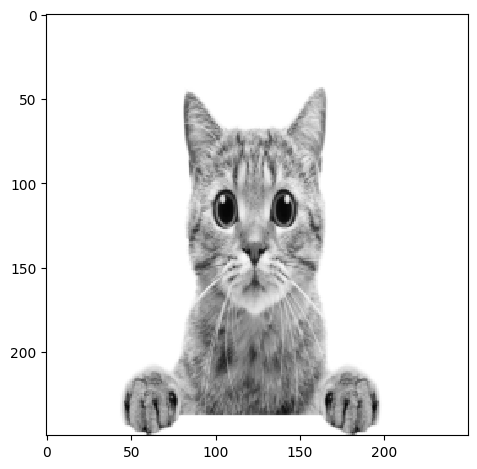

In [7]:
io.imshow(img1.reshape(250,250,1))

In [8]:
tar = target_arr[100]
tar

1

In [9]:
df = pd.DataFrame(flat_data_arry)
df.head

<bound method NDFrame.head of         0         1         2         3         4         5         6      \
0    0.521548  0.534130  0.547423  0.556567  0.557402  0.555635  0.558660   
1    1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000   
2    0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
3    0.651635  0.655698  0.627131  0.649527  0.560534  0.409465  0.651356   
4    0.820658  0.818266  0.818496  0.820231  0.823408  0.835059  0.846827   
..        ...       ...       ...       ...       ...       ...       ...   
135  0.273962  0.279203  0.275524  0.266814  0.258657  0.250016  0.247240   
136  0.281792  0.280043  0.286710  0.322191  0.423862  0.420624  0.395765   
137  0.682418  0.660711  0.628428  0.599513  0.596912  0.625108  0.626597   
138  0.766526  0.767114  0.771428  0.774553  0.776422  0.780447  0.782212   
139  0.389468  0.416781  0.398866  0.367114  0.372588  0.377012  0.333058   

        7         8         9      ...     62

In [14]:
df.shape

(140, 62501)

In [10]:
df['target']=target_arr
df.tail()

,0,1,2,3,4,5,6,7,8,9,...,62491,62492,62493,62494,62495,62496,62497,62498,62499,target
135,0.273962,0.279203,0.275524,0.266814,0.258657,0.250016,0.247240,0.243157,0.235861,0.229273,...,0.352267,0.343085,0.329292,0.325715,0.339879,0.375093,0.414554,0.439422,0.454595,1
136,0.281792,0.280043,0.286710,0.322191,0.423862,0.420624,0.395765,0.404415,0.349948,0.311975,...,0.525159,0.525456,0.523054,0.507935,0.507217,0.507317,0.507227,0.516272,0.516809,1
137,0.682418,0.660711,0.628428,0.599513,0.596912,0.625108,0.626597,0.630569,0.638057,0.628901,...,0.658478,0.668233,0.642356,0.663027,0.658043,0.659578,0.669748,0.658765,0.665200,1
138,0.766526,0.767114,0.771428,0.774553,0.776422,0.780447,0.782212,0.785153,0.786133,0.789859,...,0.159432,0.193414,0.209191,0.136360,0.233466,0.392230,0.386161,0.237930,0.018276,1
139,0.389468,0.416781,0.398866,0.367114,0.372588,0.377012,0.333058,0.295286,0.271114,0.249931,...,0.658163,0.660683,0.656965,0.658229,0.658879,0.658880,0.658571,0.656461,0.661568,1


In [18]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [19]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.20,random_state=0)

In [20]:
from sklearn.svm import SVC

clf = SVC()

clf.fit(xtrain,ytrain)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [23]:
ypred=clf.predict(xtest)
ypred

array([1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 1, 1, 1])

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix
con_mtx=confusion_matrix(ytest,ypred)
con_mtx

array([[ 4, 10],
       [ 4, 10]])

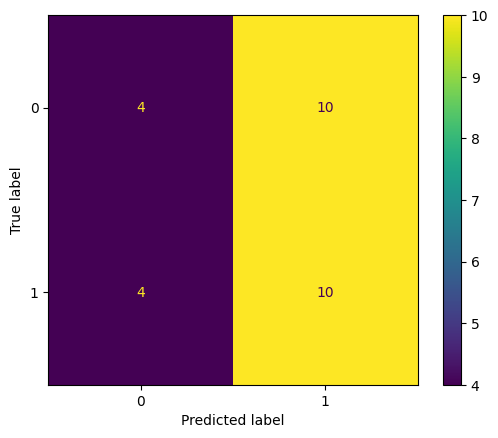

In [35]:
from matplotlib import pyplot as plt
disp=ConfusionMatrixDisplay(confusion_matrix=con_mtx,
                            display_labels=[0,1])
disp.plot()
plt.show()

In [24]:
from sklearn.metrics import classification_report
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.50      0.29      0.36        14
           1       0.50      0.71      0.59        14

    accuracy                           0.50        28
   macro avg       0.50      0.50      0.48        28
weighted avg       0.50      0.50      0.48        28



In [25]:
from sklearn.metrics import accuracy_score
acc=accuracy_score(ytest,ypred)
acc

0.5

In [26]:
ytrain_pred=clf.predict(xtrain)
ytrain_pred

array([0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0,
       1, 0])

In [27]:
from sklearn.metrics import classification_report
print(classification_report(ytrain,ytrain_pred))

              precision    recall  f1-score   support

           0       0.96      0.88      0.92        56
           1       0.89      0.96      0.92        56

    accuracy                           0.92       112
   macro avg       0.92      0.92      0.92       112
weighted avg       0.92      0.92      0.92       112



In [29]:
from sklearn.metrics import accuracy_score
acc=accuracy_score(ytrain,ytrain_pred)
acc

0.9196428571428571

In [33]:
accuracy_score(ytest,ypred)

0.5

In [30]:
if accuracy_score(ytrain,ytrain_pred)<.60:
    print("overfit")

elif accuracy_score(ytrain,ytrain_pred) > accuracy_score(ytest,ypred)+.10:
    print("underfit")

else:
    print("good fit")

underfit


In [40]:
path='dog_283.jpg'
img=imread(path)
print(img.shape)

img1=resize(img,(250,250,1))
print(img1.shape)

img2=img1.flatten()
print(img2.shape)

img3=img2.reshape(1,-1)
print(img3.shape)

(333, 500, 3)
(250, 250, 1)
(62500,)
(1, 62500)


In [41]:
out=clf.predict(img3)
out

array([1])

In [42]:
if out==0:
    print('cat')
else:
    print("dog")

dog
